# AI Companion Risk Radar — Step 1: Data Exploration & AI Subset
Reproducible EDA and subset selection for MHARD. Upload `MHARD_dataset.csv` to Colab (or mount Drive) and run top to bottom.

**Key findings (full dataset):** 200,972 reviews, 73 apps, 2011-03-29 → 2023-07-11 (≈75% from 2019–2022). No duplicate UIDs, but 6,189 duplicate app+review texts. 21 empty reviews. 74% of rows have no developer response. Ratings skew positive (60% five-star, 17% one-star). Median review is 23 words; ~6,900 are ≤3 words. App names appear to be scrubbed from review text (leaves double spaces).

**Important:** `review_cleaned` removes stopwords like *not / no / me / myself*, which carry meaning for our themes. Use raw `review` for labeling and TF-IDF.

In [ ]:
import pandas as pd, re, matplotlib.pyplot as plt
df = pd.read_csv('MHARD_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['word_count'] = df['review'].fillna('').str.split().str.len()
print(df.shape)
df.isna().sum()

(200972, 17)


,0
UID,0
app_name,0
rating,0
date,0
review,21
review_cleaned,240
likes,0
response_date,148609
response,148609
pred_gpt3.5instruct,305


In [ ]:
!ls -l MHARD_dataset.csv

-rw-r--r-- 1 root root 79390114 Sep 16 00:09 MHARD_dataset.csv


In [ ]:
print('Duplicate UIDs:', df.UID.duplicated().sum())
print('Duplicate app+review:', df.duplicated(['app_name','review']).sum())
print('Reviews <=3 words:', (df.word_count<=3).sum())
print(df.rating.value_counts(normalize=True).sort_index().round(3))
df.word_count.describe()

Duplicate UIDs: 0
Duplicate app+review: 6189
Reviews <=3 words: 6902
rating
1    0.172
2    0.044
3    0.055
4    0.125
5    0.603
Name: proportion, dtype: float64


,word_count
count,200972.000000
mean,31.157355
std,26.045604
min,0.000000
25%,11.000000
50%,23.000000
75%,44.000000
max,674.000000


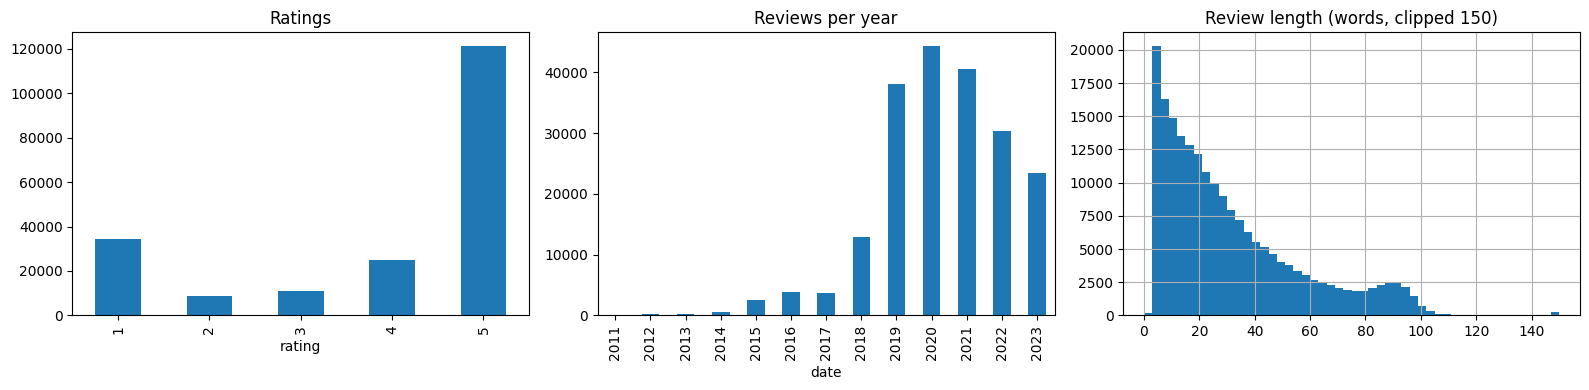

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
df.rating.value_counts().sort_index().plot.bar(ax=ax[0], title='Ratings')
df.date.dt.year.value_counts().sort_index().plot.bar(ax=ax[1], title='Reviews per year')
df.word_count.clip(upper=150).hist(bins=50, ax=ax[2]); ax[2].set_title('Review length (words, clipped 150)')
plt.tight_layout()

## Which apps are AI/chatbot-relevant?
Evidence-based check: share of each app's reviews that mention *bot / chatbot / AI / robot*.

In [ ]:
ai = r'\b(bot|chatbot|chat bot|ai|artificial intelligence|robot)\b'
df['mentions_ai'] = df.review.fillna('').str.contains(ai, case=False, regex=True)
df.groupby('app_name').agg(n=('UID','size'), ai_pct=('mentions_ai','mean'), avg_rating=('rating','mean')) \
  .sort_values('ai_pct', ascending=False).head(20).round(3)

/tmp/ipykernel_511/3515679028.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['mentions_ai'] = df.review.fillna('').str.contains(ai, case=False, regex=True)


,n,ai_pct,avg_rating
app_name,,,
wysa,1791,0.353,4.495
youper,3382,0.128,4.262
woebot,4832,0.123,4.600
amaha,5168,0.053,4.434
ifeel,94,0.021,3.404
sevencups,7384,0.018,3.735
voidpet,1013,0.017,4.634
happify,932,0.016,2.915
vos,551,0.015,3.779


**Proposed inclusion criteria (confirm with advisor):**
- **Tier 1 — core conversational AI** (the app *is* a chatbot): `wysa` (36.5% of reviews mention AI/bot), `woebot` (12.9%), `youper` (13.0%)
- **Tier 2 — AI chat feature inside a broader app** (verified by reading review mentions): `amaha` (InnerHour "Relief Bot"), `happify` (AI assistant), `healthily` (symptom chatbot), `vos` (AI journal chat), `voidpet` (AI pet chat, added 2023), `heyy` (chat bot)
- **Excluded but useful comparison group — human-support platforms:** `sevencups`, `talkspace`, `talklife`, `regain`, `teencounseling`, `besthelp`, `cerebral`, `ifeel`. Their "bot" mentions are mostly moderation bots or complaints that listeners feel robotic.
- Mentions of a mascot/robot character (e.g. `reflectly`, `finch`) do not qualify.

Caveat: Tier 2 apps contain many reviews unrelated to the AI feature. Sensitivity check later: does the model hold up on Tier 1 only?

In [ ]:
TIER = {'wysa':1,'woebot':1,'youper':1,'amaha':2,'happify':2,'healthily':2,'vos':2,'voidpet':2,'heyy':2}
s = df[df.app_name.isin(TIER)].copy()
s = s[s.review.notna()].drop_duplicates(['app_name','review'])   # drop empty + duplicate text
s = s[s.word_count >= 4]                                        # too short to carry a theme
s['tier'] = s.app_name.map(TIER)
print(len(s)); s.app_name.value_counts()

18801


,count
app_name,
amaha,5115
woebot,4671
youper,3382
wysa,1790
healthily,1226
voidpet,968
happify,886
vos,524
heyy,239


## Keyword scan (for sampling only — NOT labels)
Themes are rare, so a purely random sample will be ~90% Other/None. Keyword hits help oversample candidates. Spot checks show low precision (e.g. *crisis* often means "I was in crisis and it helped", not frustration with crisis handling), so humans must label.

In [ ]:
KW = {
 'kw_dependence': r'\b(addict\w*|depend\w*|rely|relied|reliant|lifeline|without (it|this app)|hooked|can.?t stop)\b',
 'kw_attachment': r'\b(best ?friend|friend|companion|like a (person|human|friend)|cares? about me|relationship|miss (him|her|it))\b',
 'kw_isolation':  r'\b(no one to talk|nobody to talk|lonely|loneliness|alone|better than (a |my )?(therapist|people|friends|humans?)|replace\w*|don.?t have anyone|instead of (talking|people|a therapist|therapy)|real (person|people|human))\b',
 'kw_crisis':     r'\b(suicid\w*|kill (my)?self|self.?harm|crisis|emergency|hotline|helpline|988|911)\b'}
for k,p in KW.items(): s[k] = s.review.str.contains(p, case=False, regex=True)
s[list(KW)].sum()

/tmp/ipykernel_511/907597504.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for k,p in KW.items(): s[k] = s.review.str.contains(p, case=False, regex=True)
/tmp/ipykernel_511/907597504.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for k,p in KW.items(): s[k] = s.review.str.contains(p, case=False, regex=True)
/tmp/ipykernel_511/907597504.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for k,p in KW.items(): s[k] = s.review.str.contains(p, case=False, regex=True)
/tmp/ipykernel_511/907597504.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for k,p in KW.items(): s[k] = s.review.str.contains(p, case=False, regex=True)


,0
kw_dependence,144
kw_attachment,593
kw_isolation,583
kw_crisis,170


In [ ]:
SEED = 42; parts = []; used = set()
for k in KW:
    pool = s[s[k] & ~s.UID.isin(used)]
    p = pool.sample(min(30, len(pool)), random_state=SEED); used |= set(p.UID); parts.append(p)
parts.append(s[~s.UID.isin(used)].sample(80, random_state=SEED))
pilot = pd.concat(parts).sample(frac=1, random_state=SEED)[['UID','app_name','rating','review']]
for c in ['labeler_A_primary','labeler_A_secondary','labeler_B_primary','labeler_B_secondary','final_label','notes']: pilot[c] = ''
pilot.to_csv('pilot_labeling_sample_200.csv', index=False)
s.to_csv('ai_subset_clean.csv', index=False)

## After pilot labeling: agreement
```python
from sklearn.metrics import cohen_kappa_score
lab = pd.read_csv('pilot_labeling_sample_200_labeled.csv')
cohen_kappa_score(lab.labeler_A_primary, lab.labeler_B_primary)
```
Rough guide: <0.4 means the codebook needs work; 0.6+ is solid.